# U-Net++ con ResNet34 y atención scSE, 2 capas

U-Net++ es una arquitectura *encoder-decoder* para **segmentación semántica**. El *encoder* extrae representaciones de la imagen en múltiples escalas, mientras que el *decoder* recupera progresivamente la resolución espacial para producir una máscara de segmentación. En este proyecto se aborda una tarea binaria: para cada píxel, el modelo genera un *logit* que representa su pertenencia a la clase grieta.

A diferencia de U-Net, U-Net++ incorpora rutas de conexión densas y anidadas entre el *encoder* y el *decoder*. Estas rutas procesan progresivamente las características provenientes del *encoder* antes de combinarlas con las del *decoder*, con el objetivo de reducir la diferencia semántica entre ambos conjuntos de representaciones. Debido a que este mecanismo busca conservar información espacial de alta resolución, U-Net++ constituye una arquitectura candidata prometedora para segmentar estructuras pequeñas, irregulares y delgadas, como las grietas. Esta hipótesis será evaluada mediante su comparación experimental con otras arquitecturas de segmentación. Para más detalles sobre la arquitectura original, véase el artículo [*UNet++: A Nested U-Net Architecture for Medical Image Segmentation*](https://arxiv.org/abs/1807.10165).

La implementación utiliza `UnetPlusPlus` de
[Segmentation Models PyTorch (SMP)](https://github.com/qubvel-org/segmentation_models.pytorch),
con [ResNet34](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet34.html) como *encoder*. El *encoder*
se inicializa con pesos preentrenados sobre
[ImageNet](https://www.image-net.org/).

Para el entrenamiento se utiliza una combinación con igual ponderación de **Binary Cross-Entropy** y **Dice Loss**:

$$
L = L_{\text{BCE}} + L_{\text{Dice}}
$$

En particular, se emplea `BCEWithLogitsLoss`, que combina internamente la función sigmoide con la entropía cruzada binaria de una forma numéricamente estable. BCE penaliza la clasificación incorrecta de cada píxel, mientras que Dice Loss optimiza el solapamiento entre la máscara predicha y la máscara real.

La combinación busca conservar una señal de aprendizaje píxel a píxel y, al mismo tiempo, reducir el dominio de la clase de fondo en un problema desbalanceado, donde las grietas representan una proporción pequeña del total de píxeles de la imagen.


In [15]:
# Install required third-party libraries
%uv pip install -q torch torchvision opencv-python numpy matplotlib

import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from pathlib import Path

# from models import unet_base

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

Note: you may need to restart the kernel to use updated packages.


In [16]:
%uv pip install -q segmentation-models-pytorch

import matplotlib.pyplot as plt, torch.nn as nn, segmentation_models_pytorch as smp

smp.UnetPlusPlus

Note: you may need to restart the kernel to use updated packages.


segmentation_models_pytorch.decoders.unetplusplus.model.UnetPlusPlus

In [17]:
# ==== Solo para ejecutar en Colab ========
try:
    from google.colab import drive
    import os
    import sys

    # 1. Montar Google Drive
    drive.mount('/content/drive')

    # 2. Definir la ruta a tu proyecto dentro de Drive
    # (Asegúrate de ajustar esta ruta si guardaste la carpeta en otro lado dentro de tu Drive)
    project_path = '/content/drive/MyDrive/tp_computer_vision_ii'
    notebook_dir = os.path.join(project_path, 'src', 'unet')

    # 3. Movernos al directorio donde está el notebook para que las rutas relativas funcionen
    os.chdir(notebook_dir)

    # 4. Agregar la ruta a sys.path para que Python encuentre la carpeta "models"
    if notebook_dir not in sys.path:
        sys.path.append(notebook_dir)

    print("Directorio actual:", os.getcwd())
    IN_COLAB = True

except:
    IN_COLAB = False

In [18]:
import os
import shutil
import sys
from pathlib import Path

try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

# ---------------------------------------------------------------------
# Dynamic Path Resolution (Portable across any OS / Colab / Jupyter)
# ---------------------------------------------------------------------
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and Path("/content/drive/MyDrive").exists():
    # If running in Colab with Google Drive mounted
    PROJECT_ROOT = Path("/content/drive/MyDrive/tp_computer_vision_ii")
elif IN_COLAB:
    # Colab environment without Drive mounted
    PROJECT_ROOT = Path("/content/tp_computer_vision_ii")
else:
    # Any local machine / VM: uses the current working directory
    try:
        PROJECT_ROOT = Path(__file__).resolve().parent
    except NameError:
        PROJECT_ROOT = Path.cwd()

DATASETS_DIR = PROJECT_ROOT / "datasets"
SEG_DIR = DATASETS_DIR / "dataset_1000"

REQUIRED_DIRS = (
    "train_img",
    "train_lab",
    "test_img",
    "test_lab",
)

DATASET_ID = "rukiyeaydn/deepcrack-dataset"


# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------
def is_dataset_ready(root: Path) -> bool:
    """Check if the directory contains all required DeepCrack folders."""
    return root.exists() and all((root / name).is_dir() for name in REQUIRED_DIRS)


def find_dataset_root(root: Path) -> Path | None:
    """Find the directory containing the four expected DeepCrack folders."""
    if not root.exists():
        return None

    if is_dataset_ready(root):
        return root

    for candidate in root.rglob("*"):
        if candidate.is_dir() and is_dataset_ready(candidate):
            return candidate

    return None


# ---------------------------------------------------------------------
# Dataset Preparation
# ---------------------------------------------------------------------
def prepare_segmentation(force: bool = False) -> Path:
    """Download and prepare the DeepCrack segmentation dataset portably."""
    if force and SEG_DIR.exists():
        print(f"Removing existing dataset: {SEG_DIR}")
        shutil.rmtree(SEG_DIR)

    if is_dataset_ready(SEG_DIR):
        print(f"Dataset already ready at: {SEG_DIR}")
        return SEG_DIR

    # Ensure target parent directories exist
    SEG_DIR.mkdir(parents=True, exist_ok=True)

    print(f"Downloading {DATASET_ID} from Kaggle...")
    downloaded_path = Path(kagglehub.dataset_download(DATASET_ID))
    print(f"Downloaded cache path: {downloaded_path}")

    # Locate the folder with the target structure
    source = find_dataset_root(downloaded_path)

    if source is None:
        source = find_dataset_root(SEG_DIR)

    if source is None:
        missing = [name for name in REQUIRED_DIRS if not (SEG_DIR / name).is_dir()]
        raise RuntimeError(
            f"The DeepCrack dataset was downloaded, but expected structure was not found.\n"
            f"Downloaded path: {downloaded_path}\n"
            f"Missing directories: {missing}"
        )

    # Copy files to standard project directory
    if source.resolve() != SEG_DIR.resolve():
        for name in REQUIRED_DIRS:
            source_dir = source / name
            target_dir = SEG_DIR / name
            target_dir.mkdir(parents=True, exist_ok=True)
            shutil.copytree(source_dir, target_dir, dirs_exist_ok=True)

    if not is_dataset_ready(SEG_DIR):
        raise RuntimeError(f"Dataset preparation failed under: {SEG_DIR}")

    print(f"Dataset successfully prepared at: {SEG_DIR}")
    return SEG_DIR


if __name__ == "__main__":
    prepare_segmentation()

Dataset already ready at: /root/datasets/dataset_1000


In [19]:
import os, random, cv2
import numpy as np, torch
from torch.utils.data import Dataset

class JointTransform:
    """
    Aplica las mismas transformaciones geométricas a las imágenes y las máscaras.

    Los bordes deben generarse (con Canny) después de aplicar las transformaciones
    sobre la máscara.
    """
    def __init__(
        self, 
        scale_limit=(0.5, 2.0),
        crop_size=(512, 512),
        hflip_p=0.5,
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ):
        self.scale_limit = scale_limit
        self.crop_h, self.crop_w = crop_size
        self.hflip_p = hflip_p
        self.mean = np.array(mean, dtype=np.float32)
        self.std = np.array(std, dtype=np.float32)

    def __call__(self, image, mask):
        # image: HxWx3 uint8 RGB ; mask: HxW uint8 (0/1)
        
        # Random Scale
        scale = random.uniform(*self.scale_limit)
        h, w = image.shape[:2]
        new_h, new_w = max(1, int(h * scale)), max(1, int(w * scale))
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

        # Padding (Si queda más chica que el crop)
        pad_h = max(self.crop_h - new_h, 0)
        pad_w = max(self.crop_w - new_w, 0)
        if pad_h > 0 or pad_w > 0:
            image = cv2.copyMakeBorder(image, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)
            mask = cv2.copyMakeBorder(mask, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

        # Random crop
        h, w = image.shape[:2]
        top = random.randint(0, h - self.crop_h)
        left = random.randint(0, w - self.crop_w)
        image = image[top:top + self.crop_h, left:left + self.crop_w]
        mask = mask[top:top + self.crop_h, left:left + self.crop_w]

        # Horizontal flip
        if random.random() < self.hflip_p:
            image = cv2.flip(image, 1)
            mask = cv2.flip(mask, 1)

        return image, mask

    def normalize_and_to_tensor(self, image):
        image = image.astype(np.float32) / 255.0
        image = (image - self.mean) / self.std
        return torch.from_numpy(image).permute(2, 0, 1).float()

In [20]:
class DeepCrackDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        split: 'train' o 'test'
        """
        self.root_dir = root_dir
        self.img_dir = os.path.join(self.root_dir, f"{split}_img")
        self.lab_dir = os.path.join(self.root_dir, f"{split}_lab")
        self.images = sorted(os.listdir(self.img_dir))
        self.transform = transform      # Usar JointTransform
        self.mean = np.array((0.485, 0.456, 0.406), dtype=np.float32)
        self.std = np.array((0.229, 0.224, 0.225), dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def _generate_boundary_on_the_fly(self, mask):
        # Habría que jugar un poco con los parámetros de OpenCV para optimizar resultados,
        # pero probablemente lo mejor sería un tratamiento por imagen individual
        # Aplicar Canny para detectar los bordes
        edges = cv2.Canny(mask, 10, 100)

        # Dilatación morfológica para expandir fronteras y conpensar ruido
        kernel = np.ones((3, 3), np.uint8)
        dilated_edges = cv2.dilate(edges, kernel, iterations=1)

        # Normalizar 0-1
        return (dilated_edges > 0).astype(np.float32)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Las máscaras tienen extensión .png, a diferencia de las imágenes
        # que son .jpg
        lab_name = os.path.splitext(img_name)[0] + '.png'
        lab_path = os.path.join(self.lab_dir, lab_name)

        # Cargar imágenes y máscara
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(lab_path, cv2.IMREAD_GRAYSCALE)

        # Binarizar máscara
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            # Redimensionar a un tamaño fijo para todas las imágenes del dataset
            target_size = (512, 512)
            image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

        if self.transform:
            image = self.transform.normalize_and_to_tensor(image)
        else:
            image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
            # Convertir a tensor si no hay transformación
            image = torch.from_numpy(image).permute(2, 0, 1).float()

        mask = torch.from_numpy(mask).float().unsqueeze(0)
        return image, mask

In [21]:
if device.type == "cuda":
    num_workers = 2
    print("Using CUDA with 2 workers")
else:
    num_workers = 0

train_transform = JointTransform(scale_limit=(0.5, 2.0), crop_size=(512, 512), hflip_p=0.5)

p = SEG_DIR


# Instanciar el Dataset (usando la clase DeepCrackDataset adaptada para albumentations)
train_dataset = DeepCrackDataset(root_dir=p, split='train', transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=num_workers, drop_last=True)

val_dataset = DeepCrackDataset(root_dir=p, split='test', transform=None)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=num_workers)

Using CUDA with 2 workers


In [22]:
bce_loss = nn.BCEWithLogitsLoss()


def dice_loss(logits, targets, eps=1e-6):
    probabilities = torch.sigmoid(logits)

    intersection = (probabilities * targets).sum(dim=(1, 2, 3))
    total = probabilities.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (total + eps)
    return 1 - dice.mean()

def segmentation_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)

In [23]:
@torch.no_grad()
def compute_conf_matrix(logits, targets, threshold=0.5):
    # U-Net++: [B, 1, H, W] logits -> [B, H, W] binary labels
    pred_labels = (torch.sigmoid(logits) >= threshold).long().squeeze(1)
    target_labels = targets.long().squeeze(1)

    pred_flat = pred_labels.reshape(-1)
    target_flat = target_labels.reshape(-1)

    valid = target_flat != 255
    pred_flat = pred_flat[valid]
    target_flat = target_flat[valid]

    indices = 2 * target_flat + pred_flat
    return torch.bincount(indices, minlength=4).reshape(2, 2)


def metrics_from_conf_matrix(conf_matrix):
    tp = conf_matrix.diag()
    fp = conf_matrix.sum(dim=0) - tp
    fn = conf_matrix.sum(dim=1) - tp

    denominator = tp + fp + fn
    valid_classes = denominator > 0

    iou_per_class = torch.zeros(2, dtype=torch.float32, device=conf_matrix.device)
    iou_per_class[valid_classes] = (
        tp[valid_classes].float() / denominator[valid_classes].float()
    )

    miou = iou_per_class[valid_classes].mean()

    crack_tp = tp[1].float()
    crack_fp = fp[1].float()
    crack_fn = fn[1].float()

    precision = crack_tp / (crack_tp + crack_fp).clamp_min(1)
    recall = crack_tp / (crack_tp + crack_fn).clamp_min(1)
    f1 = 2 * crack_tp / (2 * crack_tp + crack_fp + crack_fn).clamp_min(1)

    return {
        "miou": miou.item(),
        "background_iou": iou_per_class[0].item(),
        "crack_iou": iou_per_class[1].item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
    }

In [24]:
def run_epoch(
    model,
    loader,
    device,
    encoder_optimizer=None,
    decoder_optimizer=None,
    threshold=0.5,
):
    training = encoder_optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    conf_matrix = torch.zeros(2, 2, dtype=torch.long, device=device)

    with torch.set_grad_enabled(training):
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            if training:
                encoder_optimizer.zero_grad(set_to_none=True)
                decoder_optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = segmentation_loss(logits, masks)

            if training:
                loss.backward()
                encoder_optimizer.step()
                decoder_optimizer.step()

            total_loss += loss.item()
            conf_matrix += compute_conf_matrix(
                logits.detach(), masks, threshold
            )

    return total_loss / len(loader), metrics_from_conf_matrix(conf_matrix)



In [26]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_depth=2,
    encoder_weights="imagenet",
    decoder_channels=(64, 32),
    decoder_use_norm="batchnorm",
    decoder_attention_type="scse",
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

encoder_optimizer = torch.optim.SGD(
    model.encoder.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True,
)

decoder_optimizer = torch.optim.AdamW(
    list(model.decoder.parameters())
    + list(model.segmentation_head.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

checkpoint_path = Path("unet++resnet34_3layers.pt")

images, masks = next(iter(train_loader))
with torch.inference_mode():
    prediction = model(images[:1].to(device))

device, prediction.shape, masks[:1].shape, sum(p.numel() for p in model.parameters())
print(num_workers)

2


In [27]:
max_epochs = 100

In [28]:
THRESHOLD = 0.5
best_val_miou = 0.0
patience = 10
patience_counter = 0

history = {
    "train_loss": [],
    "train_miou": [],
    "train_crack_iou": [],
    "train_precision": [],
    "train_recall": [],
    "train_f1": [],
    "val_loss": [],
    "val_miou": [],
    "val_crack_iou": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
}

print("ENTRENAMIENTO INICIADO")
for epoch in range(max_epochs):
    train_loss, train_metrics = run_epoch(
        model,
        train_loader,
        device,
        encoder_optimizer=encoder_optimizer,
        decoder_optimizer=decoder_optimizer,
        threshold=THRESHOLD,
    )

    val_loss, val_metrics = run_epoch(
        model, val_loader, device,
        threshold=THRESHOLD,
    )

    history["train_loss"].append(train_loss)
    history["train_miou"].append(train_metrics["miou"])
    history["train_crack_iou"].append(train_metrics["crack_iou"])
    history["train_precision"].append(train_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])

    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_metrics["miou"])
    history["val_crack_iou"].append(val_metrics["crack_iou"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])

    print(f"--- Epoch {epoch + 1}/{max_epochs} ---")
    print(
        f"Train -> Loss: {train_loss:.4f} | "
        f"mIoU: {train_metrics['miou']:.4f} | "
        f"Crack IoU: {train_metrics['crack_iou']:.4f} | "
        f"F1: {train_metrics['f1']:.4f}"
    )
    print(
        f"Val   -> Loss: {val_loss:.4f} | "
        f"mIoU: {val_metrics['miou']:.4f} | "
        f"Crack IoU: {val_metrics['crack_iou']:.4f} | "
        f"F1: {val_metrics['f1']:.4f}"
    )

    val_miou = val_metrics["miou"]
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "encoder_optimizer_state_dict": encoder_optimizer.state_dict(),
            "decoder_optimizer_state_dict": decoder_optimizer.state_dict(),
            "val_miou": val_metrics["miou"],
            "val_background_iou": val_metrics["background_iou"],
            "val_crack_iou": val_metrics["crack_iou"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_loss": val_loss,
            "threshold": THRESHOLD,
        }, checkpoint_path)
        print(f"Mejor modelo guardado (Val mIoU: {val_miou:.4f})")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping activado en epoch {epoch + 1}")
        break

    print()

print("ENTRENAMIENTO FINALIZADO")

ENTRENAMIENTO INICIADO
--- Epoch 1/100 ---
Train -> Loss: 0.8669 | mIoU: 0.6099 | Crack IoU: 0.2731 | F1: 0.4290
Val   -> Loss: 0.4968 | mIoU: 0.7858 | Crack IoU: 0.5962 | F1: 0.7470
Mejor modelo guardado (Val mIoU: 0.7858)

--- Epoch 2/100 ---
Train -> Loss: 0.4338 | mIoU: 0.7769 | Crack IoU: 0.5694 | F1: 0.7256
Val   -> Loss: 0.4197 | mIoU: 0.7761 | Crack IoU: 0.5725 | F1: 0.7282

--- Epoch 3/100 ---
Train -> Loss: 0.3619 | mIoU: 0.7954 | Crack IoU: 0.6050 | F1: 0.7539
Val   -> Loss: 0.3562 | mIoU: 0.7966 | Crack IoU: 0.6159 | F1: 0.7623
Mejor modelo guardado (Val mIoU: 0.7966)

--- Epoch 4/100 ---
Train -> Loss: 0.3446 | mIoU: 0.8026 | Crack IoU: 0.6170 | F1: 0.7631
Val   -> Loss: 0.3454 | mIoU: 0.8094 | Crack IoU: 0.6373 | F1: 0.7784
Mejor modelo guardado (Val mIoU: 0.8094)

--- Epoch 5/100 ---
Train -> Loss: 0.3332 | mIoU: 0.8098 | Crack IoU: 0.6324 | F1: 0.7748
Val   -> Loss: 0.3757 | mIoU: 0.7892 | Crack IoU: 0.6037 | F1: 0.7528

--- Epoch 6/100 ---
Train -> Loss: 0.3152 | mIoU:

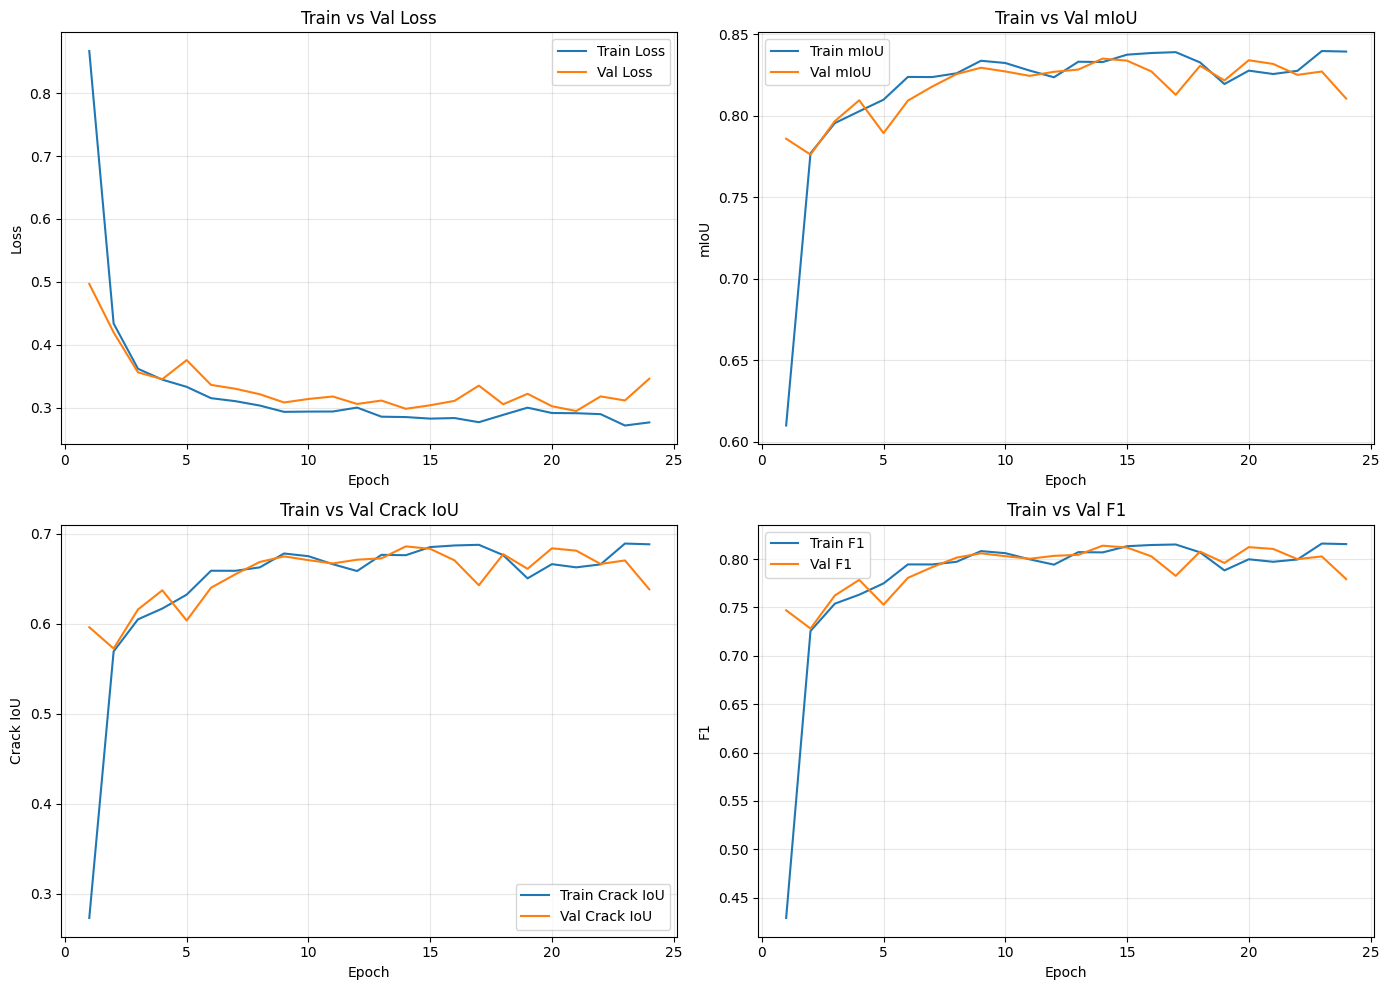


RESUMEN FINAL:
Mejor Val mIoU: 0.8350 (Epoch 14)
Val Crack IoU: 0.6860
Val Precision: 0.8417
Val Recall: 0.7877
Val F1: 0.8138
Val Loss: 0.2983


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0, 0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0, 0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0, 0].set_title("Train vs Val Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, history["train_miou"], label="Train mIoU")
axes[0, 1].plot(epochs_range, history["val_miou"], label="Val mIoU")
axes[0, 1].set_title("Train vs Val mIoU")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("mIoU")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, history["train_crack_iou"], label="Train Crack IoU")
axes[1, 0].plot(epochs_range, history["val_crack_iou"], label="Val Crack IoU")
axes[1, 0].set_title("Train vs Val Crack IoU")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Crack IoU")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_range, history["train_f1"], label="Train F1")
axes[1, 1].plot(epochs_range, history["val_f1"], label="Val F1")
axes[1, 1].set_title("Train vs Val F1")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("F1")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(history["val_miou"]))
print("\nRESUMEN FINAL:")
print(f"Mejor Val mIoU: {history['val_miou'][best_epoch]:.4f} (Epoch {best_epoch + 1})")
print(f"Val Crack IoU: {history['val_crack_iou'][best_epoch]:.4f}")
print(f"Val Precision: {history['val_precision'][best_epoch]:.4f}")
print(f"Val Recall: {history['val_recall'][best_epoch]:.4f}")
print(f"Val F1: {history['val_f1'][best_epoch]:.4f}")
print(f"Val Loss: {history['val_loss'][best_epoch]:.4f}")